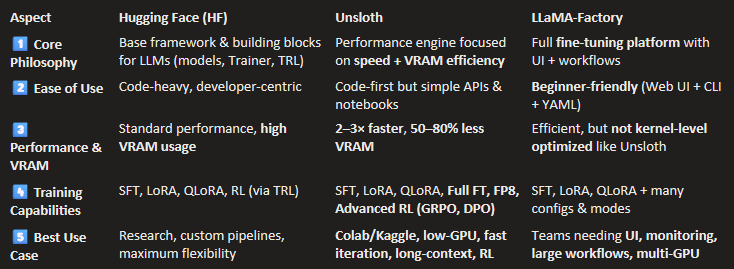

In [ ]:
# Hugging Face baseline (NO Unsloth)

# model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# HF Transformers
# bitsandbytes 4-bit
# PEFT LoRA
# Standard PyTorch kernels

# Unsloth benchmark

# model_name = "unsloth/tinyllama-bnb-4bit"

# Same base TinyLlama
# But:
# Pre-quantized
# Triton kernels
# Manual autograd
# Auto packing

In [ ]:
# torch → core deep learning engine (tensor ops, autograd, GPU kernels)
# torchvision → vision models / utils (indirect deps)
# torchaudio → audio models (indirect deps)
# xformers → memory-efficient attention kernels (important for LLMs)

In [1]:
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu128
!pip install unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

Looking in indexes: https://download.pytorch.org/whl/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.6/868.6 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 117.8 MB/s

In [2]:
# =========================
# Config
# =========================
import random
import numpy as np
import torch

# Without seed → every shuffle is different
# With seed = 3407 → the shuffle order is always the same
# Dataset shuffling
# NumPy-based preprocessing
# Augmentations

# Weight initialization on CPU
# CPU tensor randomness

# GPU randomness
# Dropout
# Attention kernels
# CUDA operations

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


#Do matrix multiplications faster, without breaking training quality.
# This controls how aggressive PyTorch is when using fast math.
# Faster & stable matmul on NVIDIA GPUs
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

max_seq_length = 4096        # Demonstrates long-context + RoPE scaling
dtype = None                # Auto-detect (FP16 on T4, BF16 on A100/L4)
load_in_4bit = True         # Memory-efficient QLoRA-style loading

In [3]:
# GPU sanity check
assert torch.cuda.is_available(), "Please enable GPU runtime (Colab → Runtime → GPU)"

In [4]:
# =========================
# Imports
# =========================
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [5]:
# =========================
# Load Base Model
# =========================
"""
We load a pre-quantized 4-bit TinyLlama model provided by Unsloth.
Benefits:
- Very low VRAM usage
- Fast download
- Perfect for Colab / Kaggle / 8–16GB GPUs
"""
BASE_MODEL_NAME = "unsloth/tinyllama-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=max_seq_length,  # Enables long-context via RoPE scaling
    dtype=dtype,                    # Auto FP16 / BF16
    load_in_4bit=load_in_4bit,      # QLoRA-style memory efficiency
)

==((====))==  Unsloth 2026.5.5: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


But with kaiokendev's RoPE scaling of 2.0, it can be magically be extended to 4096!


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/948 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear4bit(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,)

In [7]:
tokenizer

LlamaTokenizerFast(name_or_path='unsloth/tinyllama-bnb-4bit', vocab_size=32000, model_max_length=4096, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<unk>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

| Parameter                          | Value                                                           | Simple Meaning                              | Why This Is Used / Best Practice                                   |
| ---------------------------------- | --------------------------------------------------------------- | ------------------------------------------- | ------------------------------------------------------------------ |
| `FastLanguageModel.get_peft_model` | —                                                               | Converts base LLM into LoRA-trainable model | Freezes base model, trains only adapters → fast & memory efficient |
| `r` (LoRA Rank)                    | `32`                                                            | Size of LoRA adapter matrices               | Good balance between learning capacity & VRAM                      |
| `target_modules`                   | `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj` | Transformer layers where LoRA is applied    | Covers **Attention + MLP** → best fine-tuning quality              |
| `q_proj`                           | —                                                               | Query projection                            | Controls what model attends to                                     |
| `k_proj`                           | —                                                               | Key projection                              | Helps match query with information                                 |
| `v_proj`                           | —                                                               | Value projection                            | Carries actual information                                         |
| `o_proj`                           | —                                                               | Output projection                           | Final attention output                                             |
| `gate_proj`                        | —                                                               | Gating in MLP                               | Controls information flow                                          |
| `up_proj`                          | —                                                               | Expands hidden dimension                    | Increases model expressiveness                                     |
| `down_proj`                        | —                                                               | Reduces hidden dimension                    | Compresses learned features                                        |
| `lora_alpha`                       | `32`                                                            | Scaling factor for LoRA output              | `alpha = r` → stable, recommended                                  |
| `lora_dropout`                     | `0.0`                                                           | Dropout on LoRA layers                      | Unsloth recommends **0** for speed & stability                     |
| `bias`                             | `"none"`                                                        | Whether to train bias terms                 | Bias gives little gain → avoid extra params                        |
| `use_gradient_checkpointing`       | `False`                                                         | Saves VRAM by recomputation                 | Enable only for ≥7B models                                         |
| `random_state`                     | `3407`                                                          | Random seed                                 | Ensures reproducible results                                       |
| Base model parameters              | Frozen                                                          | Not trained                                 | Prevents overfitting & saves memory                                |
| LoRA parameters                    | Trainable                                                       | Only small adapters trained                 | ~0.1–1% of total parameters                                        |
| Training speed                     | Fast                                                            | —                                           | Custom CUDA kernels via Unsloth                                    |
| VRAM usage                         | Low                                                             | —                                           | 4-bit + LoRA efficiency                                            |


In [8]:
# =========================
# Apply LoRA Adapters (PEFT)
# =========================
"""
We attach LoRA adapters so that:
- Only ~1–10% parameters are trained
- Base model weights remain frozen
- Training becomes faster and memory efficient

Target modules:
- q_proj, k_proj, v_proj, o_proj → Attention
- gate_proj, up_proj, down_proj → MLP
"""

model = FastLanguageModel.get_peft_model(
    model,
    r=32,                            # LoRA rank (8/16/32/64 are common)
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=32,                   # Usually = r or 2*r
    lora_dropout=0.0,                # Unsloth recommends 0
    bias="none",                     # Best practice for LoRA
    use_gradient_checkpointing=False,# Set True if model >= 7B
    random_state=3407,               # Reproducibility
)


Unsloth 2026.5.5 patched 22 layers with 22 QKV layers, 22 O layers and 22 MLP layers.


In [9]:
model.print_trainable_parameters()

trainable params: 25,231,360 || all params: 1,125,279,744 || trainable%: 2.2422


In [10]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight
base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight
base_model.model.model.layers.0.mlp.up_proj.lora_B.default.weight
base_model.model.model.layers.0.mlp.down_proj.lora_A.default.weight
base_model.model.model.layers.0.mlp.down_proj.lora_B.default.weight
base_model.model.model.layer

In [11]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable: {trainable}")
print(f"Total: {total}")
print(f"Percent: {100 * trainable / total:.2f}%")

Trainable: 25231360
Total: 640837632
Percent: 3.94%


In [12]:
next(model.parameters()).device

device(type='cuda', index=0)

In [13]:
next(model.parameters()).dtype


torch.float16

In [14]:
from peft import PeftModel
print(isinstance(model, PeftModel))


True


In [15]:
model.peft_config

{'default': LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping={'base_model_class': 'LlamaForCausalLM', 'parent_library': 'transformers.models.llama.modeling_llama', 'unsloth_fixed': True}, peft_version='0.19.1', base_model_name_or_path='unsloth/tinyllama-bnb-4bit', revision=None, inference_mode=False, r=32, target_modules={'up_proj', 'q_proj', 'down_proj', 'o_proj', 'k_proj', 'v_proj', 'gate_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemer

In [16]:
import torch
torch.cuda.memory_summary()


'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |    824 MiB |    982 MiB |   2106 MiB |   1282 MiB |\n|       from large pool |    701 MiB |    981 MiB |   1932 MiB |   1231 MiB |\n|       from small pool |    123 MiB |    123 MiB |    174 MiB |     51 MiB |\n|---------------------------------------------------------------------------|\n| Active memory         |    824 MiB |    982 MiB |   2106 MiB |   1282 MiB |\n|       from large pool |    701 MiB |    981 MiB |

In [17]:
# batch = next(iter(trainer.get_train_dataloader()))
# outputs = model(**batch)
# outputs.loss.backward()

# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(name, param.grad is None)


In [ ]:
# inputs = tokenizer("Hello, how are you?", return_tensors="pt").to("cuda")
# with torch.no_grad():
#     out = model(**inputs)

# print(out.logits.shape)


In [ ]:
# model.eval()
# print(model.generate(**inputs, max_new_tokens=30))


|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |    826 MiB |    995 MiB |   2071 MiB |   1245 MiB |\n|       from large pool |    703 MiB |    994 MiB |   1945 MiB |   1242 MiB |\n|       from small pool |    123 MiB |    123 MiB |    126 MiB |      3 MiB |\n|---------------------------------------------------------------------------|\n| Active memory         |    826 MiB |    995 MiB |   2071 MiB |   1245 MiB |\n|       from large pool |    703 MiB |    994 MiB |

In [18]:
# =========================
# Dataset Preparation (Alpaca Format)
# =========================
"""
We convert raw Alpaca data into a single 'text' field.
IMPORTANT:
- EOS token is mandatory, otherwise generation may never stop.
"""

EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""



def format_data(examples):
    texts = []
    for instruction, input_text, output in zip(
        examples["instruction"],
        examples["input"],
        examples["output"],
    ):
        text = alpaca_prompt.format(
            instruction,
            input_text,
            output
        ) + EOS_TOKEN
        texts.append(text)
    return {"text": texts}

# Load dataset
dataset = load_dataset("yahma/alpaca-cleaned", split="train")

# Shuffle + small subset for fast demo training
dataset = dataset.shuffle(seed=3407).select(range(1500))

# Apply formatting
dataset = dataset.map(
    format_data,
    batched=True,
    remove_columns=dataset.column_names,  # keep only 'text'
)


README.md: 0.00B [00:00, ?B/s]

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [19]:
dataset

Dataset({
    features: ['text'],
    num_rows: 1500
})

In [20]:
dataset["text"][0]

'Below is an instruction that describes a task, paired with an input that provides further context.\nWrite a response that appropriately completes the request.\n\n### Instruction:\nList 5 popular dishes in US.\n\n### Input:\n\n\n### Response:\n1. Hamburger: A classic American dish consisting of a beef patty served on a bun, often topped with cheese and various toppings such as lettuce, tomatoes, onions, and condiments like ketchup and mustard.\n\n2. Macaroni & Cheese: A comforting dish made from elbow macaroni mixed with a creamy cheese sauce and often baked until golden brown and bubbly.\n\n3. Fried Chicken: A southern staple, fried chicken is typically made from pieces of chicken that are coated in a seasoned batter and deep-fried until crispy and golden brown.\n\n4. Pizza: Pizza is a beloved food in the United States, with toppings ranging from classic pepperoni and cheese to more unique combinations like pineapple and ham.\n\n5. Apple Pie: A classic American dessert made from a fla

In [21]:
# psutil = Process & System Utilities
!pip install psutil

import time, psutil

# Clears unused GPU memory
# Frees cached tensors
# Prevents fake VRAM spikes
# Reset GPU stats

# peak GPU memory used
# This line resets peak counter so:
# You measure only THIS training run
# Not previous runs / notebooks

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [22]:
# your current Python notebook process
# Used to measure CPU RAM consumption
process = psutil.Process()
train_start_time = time.time()
cpu_ram_before = process.memory_info().rss / 1024**3  # GB

In [23]:
process

psutil.Process(pid=1919, name='python3', status='running', started='10:47:43')

In [24]:
# Meaning:
# It is the number of seconds since
# 1 January 1970 (UTC)
# .776492 = fractional seconds (microsecond precision)
# Why it looks so big?
# Because:
# It’s counting seconds for ~55+ years
# That’s normal

In [25]:
train_start_time

1779360884.3603096

In [26]:
cpu_ram_before

2.552764892578125

In [30]:
# =========================
# Supervised Fine-Tuning (SFT)
# =========================
"""
We use TRL's SFTTrainer with Unsloth optimizations.
Key features:
- Sequence packing → better GPU utilization
- 8-bit optimizer → lower VRAM usage
- Gradient accumulation → simulates larger batch size
"""

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    packing=True,  # Packs multiple short samples into one sequence
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,  # Effective batch size = 8
        num_train_epochs=1,
        learning_rate=2e-5,
        warmup_ratio=0.1,               # Stabilizes early training
        optim="adamw_8bit",             # Memory efficient optimizer
        logging_steps=10,               # Progress visibility
        seed=3407,                      # Reproducibility
        output_dir="outputs",
        report_to="none",               # Disable WandB by default
    ),
)

trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,500 | Num Epochs = 1 | Total steps = 188
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 25,231,360 of 1,125,279,744 (2.24% trained)


Step,Training Loss
10,2.008500
20,1.937100
30,2.141800
40,1.968700
50,1.998100
60,2.061900
70,1.967000
80,2.078500
90,1.977300
100,1.961300


TrainOutput(global_step=188, training_loss=1.9992636213911341, metrics={'train_runtime': 292.9571, 'train_samples_per_second': 5.12, 'train_steps_per_second': 0.642, 'total_flos': 3040667617984512.0, 'train_loss': 1.9992636213911341, 'epoch': 1.0})

In [31]:
train_end_time = time.time()
cpu_ram_after = process.memory_info().rss / 1024**3  # GB

training_time_sec = round(train_end_time - train_start_time, 2)
peak_gpu_vram_gb = round(torch.cuda.max_memory_reserved() / 1024**3, 3)
cpu_ram_used_gb = round(cpu_ram_after - cpu_ram_before, 3)

print("===== UNSLOTH TRAINING STATS =====")
print(f"Training time (sec): {training_time_sec}")
print(f"Peak GPU VRAM (GB): {peak_gpu_vram_gb}")
print(f"CPU RAM used (GB): {cpu_ram_used_gb}")


===== UNSLOTH TRAINING STATS =====
Training time (sec): 909.14
Peak GPU VRAM (GB): 2.152
CPU RAM used (GB): 0.998


Deep but Simple Explanation
1️⃣ Unsloth kya karta hai?

Unsloth is NOT a trainer.

Unsloth:

⚡ Model loading optimize karta hai

⚡ LoRA / QLoRA inject karta hai

⚡ CUDA kernels optimize karta hai

⚡ Memory usage kam karta hai

⚡ Long context enable karta hai

👉 Unsloth ka kaam model preparation & acceleration hai.

model, tokenizer = FastLanguageModel.from_pretrained(...)
model = FastLanguageModel.get_peft_model(...)


⛔ Unsloth loss, backward, optimizer, epochs handle nahi karta.

2️⃣ SFTTrainer (TRL) kya karta hai?

TRL ka SFTTrainer:

📚 Dataset iterate karta hai

🧮 Loss compute karta hai

🔁 Backprop + optimizer chalata hai

🔢 Gradient accumulation

💾 Checkpoints save karta hai

📊 Logging karta hai

👉 Ye training engine hai.

3️⃣ Hugging Face Trainer directly kyun nahi?

HF Trainer:

generic hota hai

instruction tuning ke liye extra kaam

packing nahi karta

chat / alpaca formats handle nahi karta cleanly

SFTTrainer:

instruction tuning ke liye bana

text packing support

chat datasets support

LoRA friendly

In [45]:
# Save
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/tokenizer.model',
 'lora_model/added_tokens.json',
 'lora_model/tokenizer.json')

In [46]:
# Merge and save (recommended for best inference)
model.save_pretrained_merged("merged_model", tokenizer, save_method="merged_16bit")

config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:44<00:00, 44.42s/it]


Unsloth: Merge process complete. Saved to `/content/merged_model`


In [47]:
# === 1. Load the fine-tuned model (most important) ===
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "merged_model",           # or "./lora_model" or your merged folder
    max_seq_length = 2048,
    dtype = None,                     # None = auto
    load_in_4bit = True,
)

FastLanguageModel.for_inference(model)   # <- VERY IMPORTANT for speed + correctness


==((====))==  Unsloth 2026.5.5: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
The speed of light in a medium of low density is 299,792


In [48]:
# =========================
# Inference (Fast Generation)
# =========================
"""
Unsloth provides 2× faster inference using optimized kernels.
IMPORTANT:
- Always call FastLanguageModel.for_inference(model)
- Disable gradients for inference
"""

# FastLanguageModel.for_inference(model)

prompt = alpaca_prompt.format(
    "Continue the Fibonacci sequence",
    "1, 1, 2, 3, 5, 8",
    ""
)

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        use_cache=True,     # Faster decoding
        do_sample=False     # Deterministic output for demo
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Continue the Fibonacci sequence

### Response:
1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 376, 619, 958, 1597, 2776, 4813,


In [53]:
# =========================
# Inference (Fast Generation)
# =========================
"""
Unsloth provides 2× faster inference using optimized kernels.
IMPORTANT:
- Always call FastLanguageModel.for_inference(model)
- Disable gradients for inference
"""

# FastLanguageModel.for_inference(model)

prompt = alpaca_prompt.format(
    "List 5 popular dishes in US",
    "",
    ""
)

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=25,
        use_cache=True,     # Faster decoding
        do_sample=False     # Deterministic output for demo
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
List 5 popular dishes in US

### Response:

1. Fried rice
2. Chicken
3. Pizza
4. Hamburger
5. Chips


In [54]:
FastLanguageModel.for_inference(model)

prompt = "Explain LoRA in very simple words."
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        use_cache=True,
        do_sample=False
    )

torch.cuda.synchronize()
t1 = time.time()

generated_tokens = outputs.shape[-1]
tokens_per_sec = round(generated_tokens / (t1 - t0), 2)

print("===== INFERENCE STATS =====")
print(f"Generated tokens: {generated_tokens}")
print(f"Tokens per second: {tokens_per_sec}")


===== INFERENCE STATS =====
Generated tokens: 138
Tokens per second: 15.82


In [55]:
# =========================
# Save LoRA Adapters
# =========================
"""
This saves ONLY the LoRA adapters, not the full base model.
Benefits:
- Very small size (~50–200 MB)
- Can be merged later into FP16 / 4-bit / GGUF
- Easy to share or version-control
"""

LORA_SAVE_PATH = "lora_model"

model.save_pretrained(LORA_SAVE_PATH)
tokenizer.save_pretrained(LORA_SAVE_PATH)

print(f"LoRA adapters saved at: {LORA_SAVE_PATH}")


LoRA adapters saved at: lora_model


In [ ]:
# Hugging Face baseline (NO Unsloth)

# model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# HF Transformers
# bitsandbytes 4-bit
# PEFT LoRA
# Standard PyTorch kernels

In [ ]:
# Unsloth benchmark

# model_name = "unsloth/tinyllama-bnb-4bit"

# Same base TinyLlama
# But:
# Pre-quantized
# Triton kernels
# Manual autograd
# Auto packing
# Faster attention

In [ ]:
# When NOT to use Unsloth:
# - If you need heavy multi-node distributed training
# - If you want no-code UI only (LLaMA-Factory better)
# - If training classical ML models (not LLMs)


✅ Absolute Truth (No Marketing, No Confusion)

At the end of the day, sab kuch Python code hi hai jo Hugging Face ne PyTorch / TensorFlow me likha,
usi se Transformers library bani,
usi Transformers ke models HF Hub par hote hain,
aur Unsloth unhi models ko optimize karta hai.

✔️ YES. Period.

🔩 Step-by-step Reality (Code-level thinking)
1️⃣ Models kisne likhe?

Hugging Face ne Transformer architectures likhe

PyTorch / TensorFlow ke upar

Example:

LlamaForCausalLM

MistralForCausalLM

GemmaForCausalLM

➡️ Ye sab Python classes hain.

2️⃣ HF Hub kya hai?

Bas model weights + config + tokenizer files

Nothing magical

.bin, .safetensors, config.json

➡️ Model logic toh Transformers library me already likha hua hai

3️⃣ Unsloth actually kya karta hai?

Unsloth:

HF ke model class ko hi load karta hai

Same config.json

Same tokenizer

Same weights

Bas:

⚡ Faster attention kernels

⚡ Better memory layout

⚡ Optimized LoRA injection

⚡ Long context tricks

👉 Model change nahi hota, execution optimized hota hai

4️⃣ Training ka kaam kaun karta hai?

Not Unsloth.

Training loop:

Loss

Backward

Optimizer

Epochs

➡️ Ye sab TRL / HF Trainer karta hai